<a href="https://colab.research.google.com/github/sayalivadya1654-cell/Car-Resale-Price-Prediction/blob/main/Car_Resale_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [95]:
# import required libaries
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [27]:
# load dataset
df = pd.read_csv("/content/used_cars_dataset.csv")

In [26]:
df.shape

(1050, 14)

In [29]:
df.head()

,S.No.,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
0,0,Nissan Terrano XV,Hyderabad,2007,127225,Diesel,Automatic,Second,24.16 kmpl,1561 CC,131.39 bhp,7.0,41.3 Lakh,10.89
1,1,Hyundai i20 Sportz,Pune,2010,102800,Diesel,Automatic,First,19.29 kmpl,1973 CC,204.57 bhp,5.0,NaN,18.96
2,2,Skoda Yeti Ambition,Delhi,2006,120317,Diesel,Manual,First,19.3 kmpl,2186 CC,175.17 bhp,7.0,63.11 Lakh,15.79
3,3,Audi Q3 2.0 TDI,Hyderabad,2015,49027,Diesel,Automatic,First,18.88 kmpl,1812 CC,203.29 bhp,7.0,98.2 Lakh,63.75
4,4,Hyundai i10 Magna,Pune,2007,207392,Diesel,Automatic,First,25.22 kmpl,1181 CC,89.93 bhp,7.0,30.37 Lakh,8.83


In [30]:
df.tail()

,S.No.,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
1045,1045,Hyundai i20 Sportz,Bangalore,2011,76927,Diesel,Manual,Second,26.88 kmpl,1100 CC,96.23 bhp,5.0,33.28 Lakh,12.75
1046,1046,Honda BR-V VX i-DTEC,Coimbatore,2014,86847,Diesel,Automatic,First,24.53 kmpl,1523 CC,114.39 bhp,7.0,38.73 Lakh,20.52
1047,1047,Ford Endeavour Titanium,Bangalore,2015,43170,Diesel,Automatic,Second,24.43 kmpl,1364 CC,119.15 bhp,7.0,35.18 Lakh,18.99
1048,1048,Hyundai i20 Sportz,Mumbai,2008,136828,Petrol,Manual,Third,24.74 kmpl,1288 CC,97.69 bhp,7.0,NaN,7.08
1049,1049,Maruti Alto 800 LXI,Ahmedabad,2005,109477,Diesel,Manual,Second,25.8 kmpl,925 CC,93.91 bhp,5.0,NaN,6.96


In [32]:
df.columns

Index(['S.No.', 'Name', 'Location', 'Year', 'Kilometers_Driven', 'Fuel_Type',
       'Transmission', 'Owner_Type', 'Mileage', 'Engine', 'Power', 'Seats',
       'New_Price', 'Price'],
      dtype='object')

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1050 entries, 0 to 1049
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   S.No.              1050 non-null   int64  
 1   Name               1050 non-null   object 
 2   Location           1050 non-null   object 
 3   Year               1050 non-null   int64  
 4   Kilometers_Driven  1050 non-null   int64  
 5   Fuel_Type          1050 non-null   object 
 6   Transmission       1050 non-null   object 
 7   Owner_Type         1050 non-null   object 
 8   Mileage            1050 non-null   object 
 9   Engine             1050 non-null   object 
 10  Power              1050 non-null   object 
 11  Seats              1050 non-null   float64
 12  New_Price          684 non-null    object 
 13  Price              1050 non-null   float64
dtypes: float64(2), int64(3), object(9)
memory usage: 115.0+ KB


In [33]:
df.duplicated().sum()

np.int64(0)

In [24]:
df.isnull().sum()

,0
S.No.,0
Name,0
Location,0
Year,0
Kilometers_Driven,0
Fuel_Type,0
Transmission,0
Owner_Type,0
Mileage,0
Engine,0


In [35]:
df = df.drop(columns=["New_Price"])

In [36]:
df.shape

(1050, 13)

In [37]:
df = df.drop(columns=["S.No."])

In [38]:
df.shape

(1050, 12)

In [46]:
# conver mileage
df['Mileage'] = df['Mileage'].astype(str).str.split().str[0].astype(float)

In [47]:
# convert engine
df['Engine'] = df['Engine'].astype(str).str.split().str[0].astype(float)

In [48]:
# convert power
df['Power'] = df['Power'].astype(str).str.split().str[0].astype(float)

In [51]:
df.dtypes

,0
Name,object
Location,object
Year,int64
Kilometers_Driven,int64
Fuel_Type,object
Transmission,object
Owner_Type,object
Mileage,float64
Engine,float64
Power,float64


In [54]:
df.isnull().sum()

,0
Name,0
Location,0
Year,0
Kilometers_Driven,0
Fuel_Type,0
Transmission,0
Owner_Type,0
Mileage,0
Engine,0
Power,0


In [52]:
df.describe()

,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Price
count,1050.000000,1050.000000,1050.000000,1050.000000,1050.000000,1050.000000,1050.000000
mean,2008.472381,130799.327619,22.567010,1597.949524,140.077210,5.599048,17.445543
std,6.363751,94589.638057,4.334895,541.023704,52.757678,1.040733,14.308786
min,1998.000000,4302.000000,8.000000,796.000000,53.570000,4.000000,2.270000
25%,2003.000000,53348.000000,20.072500,1187.250000,99.772500,5.000000,7.152500
50%,2009.000000,115178.000000,22.980000,1507.000000,130.740000,5.000000,12.925000
75%,2014.000000,186293.000000,25.560000,1914.250000,170.675000,7.000000,23.630000
max,2019.000000,569566.000000,32.880000,3469.000000,374.400000,7.000000,100.310000


In [55]:
# categorical values
df['Fuel_Type'].value_counts()
df['Transmission'].value_counts()
df['Owner_Type'].value_counts()

,count
Owner_Type,
First,703
Second,265
Third,59
Fourth & Above,23


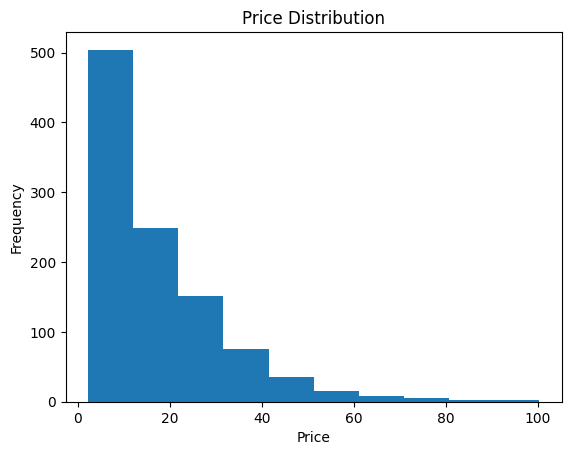

In [60]:
# histogram
plt.hist(df['Price'])
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.title("Price Distribution")
plt.show()

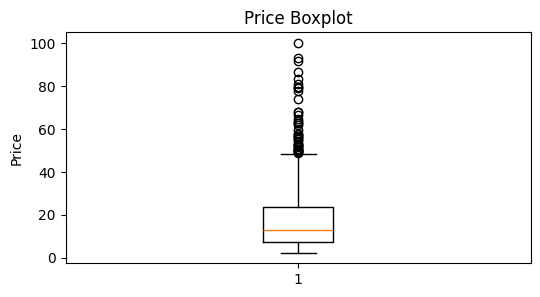

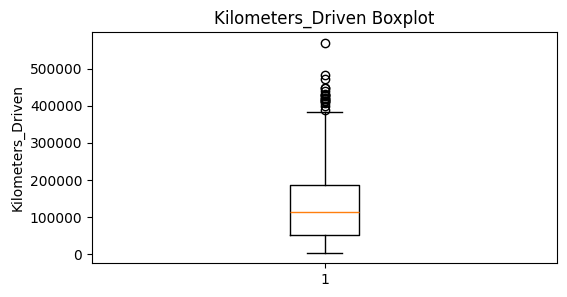

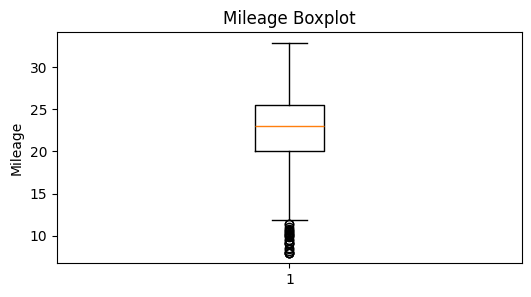

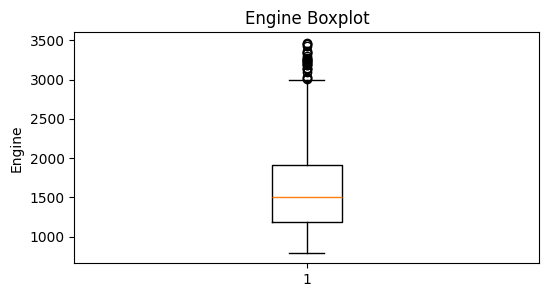

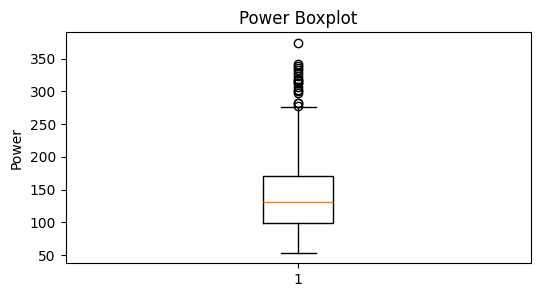

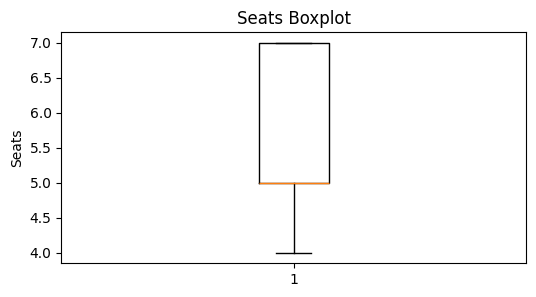

In [62]:
columns = ['Price', 'Kilometers_Driven', 'Mileage', 'Engine', 'Power', 'Seats']
for col in columns:
    plt.figure(figsize=(6, 3))
    plt.boxplot(df[col])
    plt.title(f'{col} Boxplot')
    plt.ylabel(col)
    plt.show()

In [63]:
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower:", lower)
print("Upper:", upper)

Lower: -17.563750000000002
Upper: 48.346250000000005


In [64]:
outliers = df[df['Price'] > 48.35]

print("Number of outliers:", len(outliers))

Number of outliers: 43


In [65]:
outliers[['Name', 'Year', 'Kilometers_Driven', 'Price']]

,Name,Year,Kilometers_Driven,Price
3,Audi Q3 2.0 TDI,2015,49027,63.75
22,Toyota Corolla Altis VL,2019,16597,52.18
34,Volkswagen Ameo Highline,2019,22386,50.05
43,Mini Cooper S,2016,47027,79.09
72,Skoda Rapid Ambition,2017,25196,52.50
90,Mini Countryman Cooper D,2019,10791,86.56
103,Skoda Yeti Ambition,2019,7872,49.83
125,Volkswagen Jetta Highline,2018,13525,51.94
140,Jeep Compass Longitude,2019,9682,50.91
142,Volvo XC60 D4,2019,12074,83.55


In [66]:
df.describe()

,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Price
count,1050.000000,1050.000000,1050.000000,1050.000000,1050.000000,1050.000000,1050.000000
mean,2008.472381,130799.327619,22.567010,1597.949524,140.077210,5.599048,17.445543
std,6.363751,94589.638057,4.334895,541.023704,52.757678,1.040733,14.308786
min,1998.000000,4302.000000,8.000000,796.000000,53.570000,4.000000,2.270000
25%,2003.000000,53348.000000,20.072500,1187.250000,99.772500,5.000000,7.152500
50%,2009.000000,115178.000000,22.980000,1507.000000,130.740000,5.000000,12.925000
75%,2014.000000,186293.000000,25.560000,1914.250000,170.675000,7.000000,23.630000
max,2019.000000,569566.000000,32.880000,3469.000000,374.400000,7.000000,100.310000


In [67]:
# categorical values
print(df['Fuel_Type'].value_counts())
print(df['Transmission'].value_counts())
print(df['Owner_Type'].value_counts())

Fuel_Type
Diesel    535
Petrol    466
CNG        42
LPG         7
Name: count, dtype: int64
Transmission
Manual       569
Automatic    481
Name: count, dtype: int64
Owner_Type
First             703
Second            265
Third              59
Fourth & Above     23
Name: count, dtype: int64


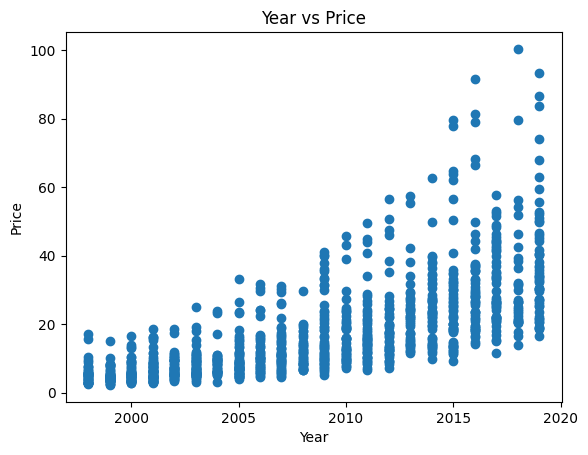

In [68]:
# scatter plot
plt.scatter(df['Year'], df['Price'])
plt.xlabel('Year')
plt.ylabel('Price')
plt.title('Year vs Price')
plt.show()

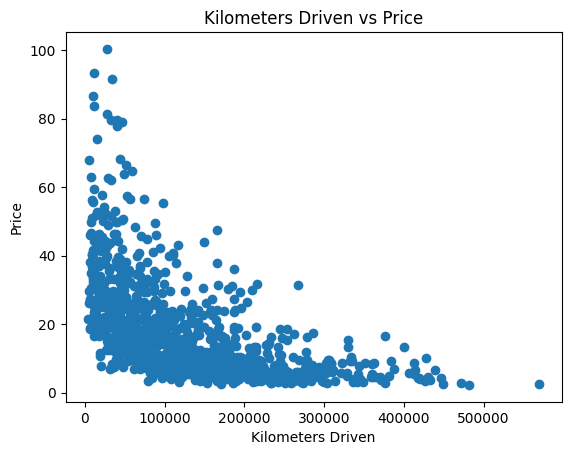

In [69]:
plt.scatter(df['Kilometers_Driven'], df['Price'])
plt.xlabel('Kilometers Driven')
plt.ylabel('Price')
plt.title('Kilometers Driven vs Price')
plt.show()

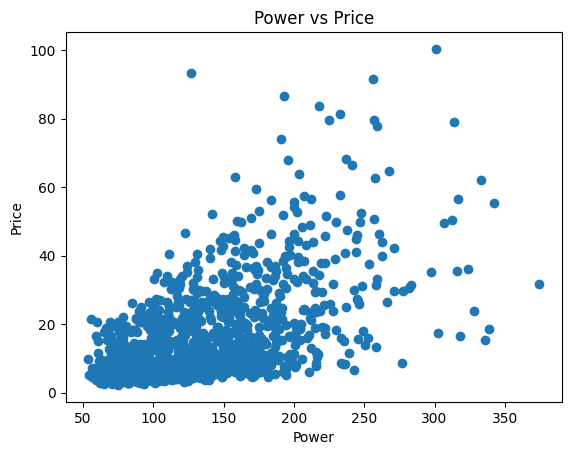

In [70]:
plt.scatter(df['Power'], df['Price'])
plt.xlabel('Power')
plt.ylabel('Price')
plt.title('Power vs Price')
plt.show()

In [71]:
current_year = 2026
df["Car_Age"] = current_year - df["Year"]

In [73]:
df[["Year", "Car_Age"]].head(10)

,Year,Car_Age
0,2007,19
1,2010,16
2,2006,20
3,2015,11
4,2007,19
5,1999,27
6,2017,9
7,2019,7
8,2012,14
9,2010,16


In [115]:
df["Brand"] = df["Name"].str.split().str[0]

print(df["Brand"].value_counts().head(20))

Brand
Maruti        136
Hyundai       132
Tata           92
Mahindra       80
Toyota         74
Honda          72
Volkswagen     62
Ford           60
Renault        51
Skoda          50
Nissan         40
Chevrolet      38
Jeep           22
Audi           17
BMW            16
Datsun         15
Mini           13
Land           13
Mitsubishi     12
Fiat           12
Name: count, dtype: int64


In [116]:
df.columns

Index(['Name', 'Location', 'Year', 'Kilometers_Driven', 'Fuel_Type',
       'Transmission', 'Owner_Type', 'Mileage', 'Engine', 'Power', 'Seats',
       'Price', 'Car_Age', 'Brand'],
      dtype='object')

In [128]:
# select X and y
X = df[
    [
        "Brand",
        "Location",
        "Car_Age",
        "Kilometers_Driven",
        "Fuel_Type",
        "Transmission",
        "Owner_Type",
        "Mileage",
        "Engine",
        "Power",
        "Seats"
    ]
]
y = df["Price"]

In [129]:
print("X shape: ", X.shape)
print("Y shape: ", y.shape)

X shape:  (1050, 11)
Y shape:  (1050,)


In [130]:
X = pd.get_dummies(X, drop_first=True)

In [131]:
# Define categorical and numerical columns
categorical_cols = [
    "Brand",
    "Location",
    "Fuel_Type",
    "Transmission",
    "Owner_Type"
]

numerical_cols = [
    "Car_Age",
    "Kilometers_Driven",
    "Mileage",
    "Engine",
    "Power",
    "Seats"
]

In [133]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [134]:
print("X_train:", X_train.shape[0])
print("X_test :", X_test.shape[0])
print("y_train:", y_train.shape[0])
print("y_test :", y_test.shape[0])

X_train: 840
X_test : 210
y_train: 840
y_test : 210


In [136]:
# Create Linear Regression Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_cols
        )
    ],
    remainder="passthrough"
)

model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

In [137]:
# linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [140]:
# Make predictions
y_pred = model.predict(X_test)
print(y_pred[:10])

[12.07241051 22.34537285  6.51676618 -4.7410087   1.34835871 52.30737721
 -0.11030368 14.16173087 33.0817227  14.23236867]


In [143]:
# error metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 3.8000588389885754
MSE : 28.68314710955941
RMSE: 5.3556649549387805
R²  : 0.8252943418449371


In [144]:
# compare actual vs predicated
comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})
print(comparison.head(10))

   Actual Price  Predicted Price
0          9.02        12.072411
1         20.05        22.345373
2          6.66         6.516766
3          3.35        -4.741009
4          5.59         1.348359
5         56.60        52.307377
6          4.83        -0.110304
7          9.48        14.161731
8         38.07        33.081723
9          9.65        14.232369


In [145]:
# save model
import pickle
with open("car_price_model.pkl", "wb") as file:
    pickle.dump(model, file)
print("Model saved successfully!")

Model saved successfully!
